### 2.1 Imports and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.spatial.distance import jensenshannon

df = pd.read_csv('df_pca.csv')
print(f'Loaded {len(df):,} rows')
print(df[['PC1', 'PC2', 'PC3', 'PC4', 'Stage']].head())

Loaded 91,709 rows
        PC1       PC2       PC3       PC4                Stage
0  0.093323  1.486236  0.479126 -1.053577  Stage 1 (2017-2019)
1 -0.071947  0.215021 -0.988435  0.958771  Stage 1 (2017-2019)
2  1.040625 -0.218344 -0.742067  0.919837  Stage 1 (2017-2019)
3 -0.361769 -1.774901  0.536522 -1.350242  Stage 1 (2017-2019)
4 -1.202927 -0.118441  0.343824 -0.897204  Stage 1 (2017-2019)


### 2.2 Elbow Method — Selecting K

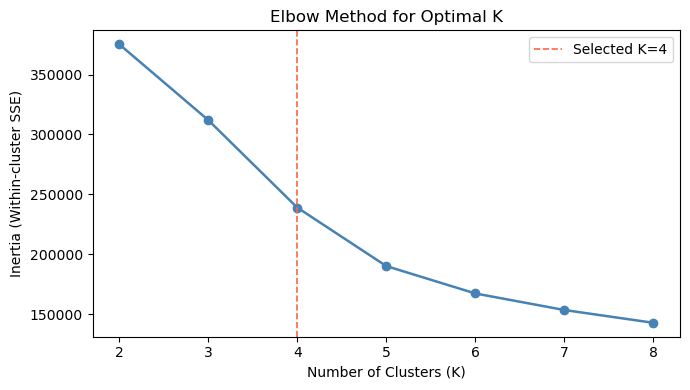

In [3]:
X = df[['PC1', 'PC2', 'PC3', 'PC4']].values

k_range = range(2, 9)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=1.8)
ax.axvline(x=4, color='tomato', linestyle='--', linewidth=1.2, label='Selected K=4')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster SSE)')
ax.set_title('Elbow Method for Optimal K')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

### 2.3 Fit K-means with K=4

In [4]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X)

print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    14622
1    24785
2    51086
3     1216
Name: count, dtype: int64


### 2.4 Interpret Clusters via Centroid Audio Features

In [5]:
AUDIO_FEATURES = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
                  'Acousticness', 'Instrumentalness', 'Valence']

centroids = df.groupby('Cluster')[AUDIO_FEATURES].mean().round(3)
print(centroids.to_string())

         Danceability  Energy  Loudness  Speechiness  Acousticness  Instrumentalness  Valence
Cluster                                                                                      
0               0.760   0.600    -6.685        0.273         0.196             0.005    0.470
1               0.565   0.479    -8.320        0.056         0.471             0.008    0.344
2               0.707   0.729    -4.991        0.071         0.145             0.003    0.600
3               0.494   0.439   -15.081        0.072         0.334             0.605    0.245


### 2.5 Name the Clusters

Looking at the centroid values from section 2.4, each cluster has a fairly distinct audio profile:

Cluster 0 has noticeably high danceability (0.76) and speechiness (0.273), which suggests this group is dominated by rap and hip-hop tracks. We label it "Hip-hop / Rap Dance".

Cluster 1 stands out for its high acousticness (0.471) and low energy (0.479), with the lowest valence among all clusters (0.344). These are likely slower, more subdued songs — labelled "Mellow Acoustic".

Cluster 2 is the largest group and has the highest energy (0.729) and valence (0.600), with relatively low acousticness. This fits mainstream upbeat pop well — labelled "Energetic Pop".

Cluster 3 is a small but clear outlier: instrumentalness is 0.605, far above any other cluster. These are mostly non-vocal tracks — labelled "Instrumental".

In [6]:
CLUSTER_NAMES = {
    0: 'Hip-hop / Rap Dance',
    1: 'Mellow Acoustic',
    2: 'Energetic Pop',
    3: 'Instrumental'
}

df['Cluster_Name'] = df['Cluster'].map(CLUSTER_NAMES)
print(df['Cluster_Name'].value_counts())

Cluster_Name
Energetic Pop          51086
Mellow Acoustic        24785
Hip-hop / Rap Dance    14622
Instrumental            1216
Name: count, dtype: int64


### 2.6 Cluster Distribution Across Three Stages

In [7]:
stage_order = ['Stage 1 (2017-2019)', 'Stage 2 (2020-2022)', 'Stage 3 (2023-2025)']
stage_labels = ['Pre-pandemic', 'Pandemic', 'Post-pandemic']

# proportion of each cluster per stage
stage_dist = (
    df.groupby(['Stage', 'Cluster_Name'])
    .size()
    .unstack(fill_value=0)
    .loc[stage_order]
)
stage_dist_pct = stage_dist.div(stage_dist.sum(axis=1), axis=0) * 100
stage_dist_pct.index = stage_labels
print(stage_dist_pct.round(2))

Cluster_Name   Energetic Pop  Hip-hop / Rap Dance  Instrumental  \
Pre-pandemic           56.72                21.85          0.56   
Pandemic               53.79                17.51          1.00   
Post-pandemic          56.68                 7.90          2.51   

Cluster_Name   Mellow Acoustic  
Pre-pandemic             20.87  
Pandemic                 27.70  
Post-pandemic            32.91  


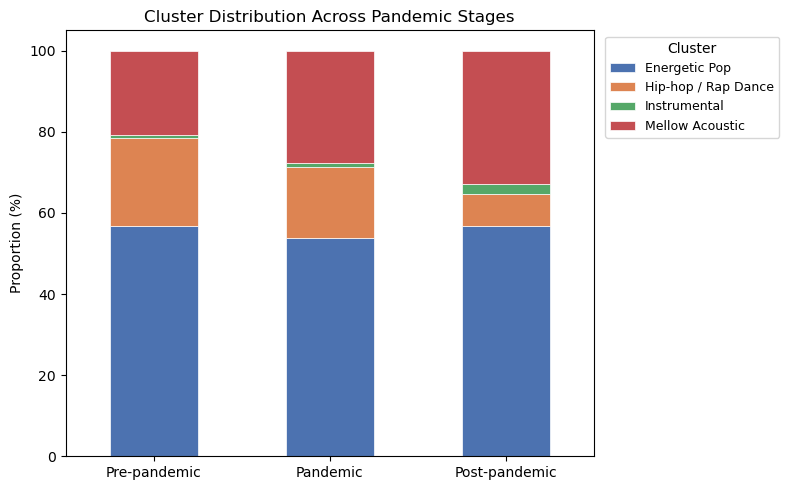

In [8]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

ax = stage_dist_pct.plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color=colors, edgecolor='white', linewidth=0.5
)
ax.set_xlabel('')
ax.set_ylabel('Proportion (%)')
ax.set_title('Cluster Distribution Across Pandemic Stages')
ax.set_xticklabels(stage_labels, rotation=0)
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('cluster_stacked_bar.png', dpi=150)
plt.show()

### 2.7 JS Divergence — Does Post-pandemic Revert to Pre or Continue Pandemic?

In [9]:
# each row in stage_dist_pct sums to 100, so divide by 100 to get proper probabilities
dist_pre  = stage_dist_pct.loc['Pre-pandemic'].values / 100
dist_pan  = stage_dist_pct.loc['Pandemic'].values / 100
dist_post = stage_dist_pct.loc['Post-pandemic'].values / 100

# jensenshannon requires no zero values, add tiny value just in case
eps = 1e-9
dist_pre  = dist_pre  + eps
dist_pan  = dist_pan  + eps
dist_post = dist_post + eps

# re-normalise so everything still sums to 1
dist_pre  /= dist_pre.sum()
dist_pan  /= dist_pan.sum()
dist_post /= dist_post.sum()

js_post_vs_pre = jensenshannon(dist_post, dist_pre)
js_post_vs_pan = jensenshannon(dist_post, dist_pan)
js_pre_vs_pan  = jensenshannon(dist_pre,  dist_pan)

print(f'JS(Post vs Pre-pandemic)  : {js_post_vs_pre:.4f}')
print(f'JS(Post vs Pandemic)      : {js_post_vs_pan:.4f}')
print(f'JS(Pre vs Pandemic) [ref] : {js_pre_vs_pan:.4f}')

if js_post_vs_pre < js_post_vs_pan:
    print('\nConclusion: Post-pandemic distribution is closer to Pre-pandemic -> REVERSION')
else:
    print('\nConclusion: Post-pandemic distribution is closer to Pandemic -> CONTINUATION')

JS(Post vs Pre-pandemic)  : 0.1648
JS(Post vs Pandemic)      : 0.1110
JS(Pre vs Pandemic) [ref] : 0.0641

Conclusion: Post-pandemic distribution is closer to Pandemic -> CONTINUATION


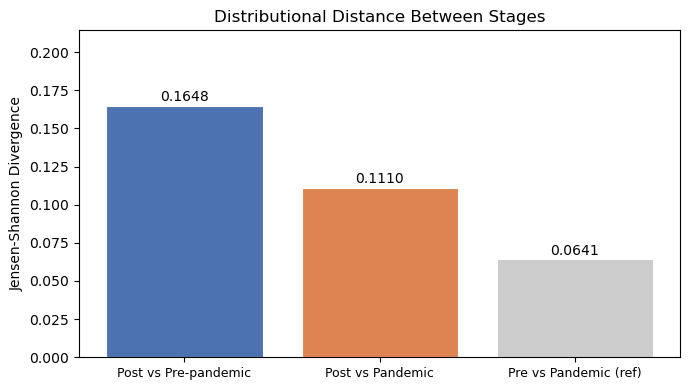

In [10]:
# visualise JS distances as a bar chart
labels = ['Post vs Pre-pandemic', 'Post vs Pandemic', 'Pre vs Pandemic (ref)']
values = [js_post_vs_pre, js_post_vs_pan, js_pre_vs_pan]
bar_colors = ['#4C72B0', '#DD8452', '#cccccc']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_ylabel('Jensen-Shannon Divergence')
ax.set_title('Distributional Distance Between Stages')
ax.set_ylim(0, max(values) * 1.3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.xticks(fontsize=9)
plt.tight_layout()
plt.savefig('js_divergence_bar.png', dpi=150)
plt.show()

### 2.8 Export — CSV with Cluster Labeles

In [12]:
df.to_csv('df_clustered.csv', index=False)
print(f'Saved df_clustered.csv with {len(df):,} rows')
print('Columns added: Cluster, Cluster_Name')
print(df[['Title', 'Stage', 'Cluster', 'Cluster_Name']].head(10))

Saved df_clustered.csv with 91,709 rows
Columns added: Cluster, Cluster_Name
                                               Title                Stage  \
0                                            Starboy  Stage 1 (2017-2019)   
1                                             Closer  Stage 1 (2017-2019)   
2            Rockabye (feat. Sean Paul & Anne-Marie)  Stage 1 (2017-2019)   
3                                    Let Me Love You  Stage 1 (2017-2019)   
4  I Don't Wan Live Forever (Fifty Shades Darker)...  Stage 1 (2017-2019)   
5                                     Don't Wan Know  Stage 1 (2017-2019)   
6                                          Fake Love  Stage 1 (2017-2019)   
7                               Say You Won't Let Go  Stage 1 (2017-2019)   
8                                   I Feel It Coming  Stage 1 (2017-2019)   
9                                          24K Magic  Stage 1 (2017-2019)   

   Cluster         Cluster_Name  
0        0  Hip-hop / Rap Dance  
1      